In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import PowerTransformer,FunctionTransformer
from scipy.stats import probplot
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,r2_score
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv('/content/aug_train.csv')

In [ ]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


In [ ]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [ ]:
df['target'].value_counts()

,count
target,
0.0,14381
1.0,4777


In [ ]:
df.drop(columns=['enrollee_id','gender','company_size','company_type'],inplace=True)

In [ ]:
df.head()

,city,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,last_new_job,training_hours,target
0,city_103,0.920,Has relevent experience,no_enrollment,Graduate,STEM,>20,1,36,1.0
1,city_40,0.776,No relevent experience,no_enrollment,Graduate,STEM,15,>4,47,0.0
2,city_21,0.624,No relevent experience,Full time course,Graduate,STEM,5,never,83,0.0
3,city_115,0.789,No relevent experience,NaN,Graduate,Business Degree,<1,never,52,1.0
4,city_162,0.767,Has relevent experience,no_enrollment,Masters,STEM,>20,4,8,0.0


In [ ]:
df['experience'].value_counts()

,count
experience,
>20,3286
5,1430
4,1403
3,1354
6,1216
2,1127
7,1028
10,985
9,980


In [ ]:
df.isnull().sum()

,0
city,0
city_development_index,0
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
last_new_job,423
training_hours,0
target,0


In [ ]:
trf1=ColumnTransformer([('impute_data',SimpleImputer(strategy='most_frequent'),[3,4,5,6,7])],remainder='passthrough')

In [ ]:
X=df.drop(columns=['target'])
y=df['target']

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
trf1.fit_transform(X_train)[0]

array(['no_enrollment', 'Graduate', 'STEM', '2', '1', 'city_21', 0.624,
       'Has relevent experience', 134], dtype=object)

In [ ]:
X_train.head(1)

,city,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,last_new_job,training_hours
7869,city_21,0.624,Has relevent experience,no_enrollment,Graduate,STEM,2,1,134


In [47]:
X_train['last_new_job'].value_counts().index

Index(['1', '>4', '2', 'never', '4', '3'], dtype='object', name='last_new_job')

In [50]:
trf2=ColumnTransformer([('transform',OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first'),[5,2]),
 ('encoded_Univesity_enrolled',OrdinalEncoder(categories=[['no_enrollment','Part time course','Full time course']],),[0]),
 ('Encoded_Education_level',OrdinalEncoder(categories=[['Primary School','High School','Graduate','Masters','Phd']]),[1]),
  ('encoded_experince',OrdinalEncoder(categories=[['<1','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','>20']]),[3]),
                        ('encoded_last_new_job',OrdinalEncoder(categories=[['never','1','2','3','4','>4']]),[4]),
                        ('encoded_relevent_experience',OrdinalEncoder(categories=[['No relevent experience','Has relevent experience']]),[7])],remainder='passthrough')

In [51]:
pipe=Pipeline([('trf1',trf1),('trf2',trf2)])

In [53]:
pipe.fit_transform(X_train)

array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 1.0,
       1.0, 0.624, 134], dtype=object)

In [82]:
xx=X_train.drop(columns=['city','relevent_experience','enrolled_university','education_level','major_discipline','experience','last_new_job'])
xx

,city_development_index,training_hours
7869,0.624,134
2884,0.920,58
7207,0.920,206
3807,0.624,28
1861,0.624,35
...,...,...
1099,0.855,13
18898,0.920,6
11798,0.920,120
6637,0.920,48


/tmp/ipykernel_987/1597214061.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=xx[cols],ax=a1)
/tmp/ipykernel_987/1597214061.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=xx[cols],ax=a1)


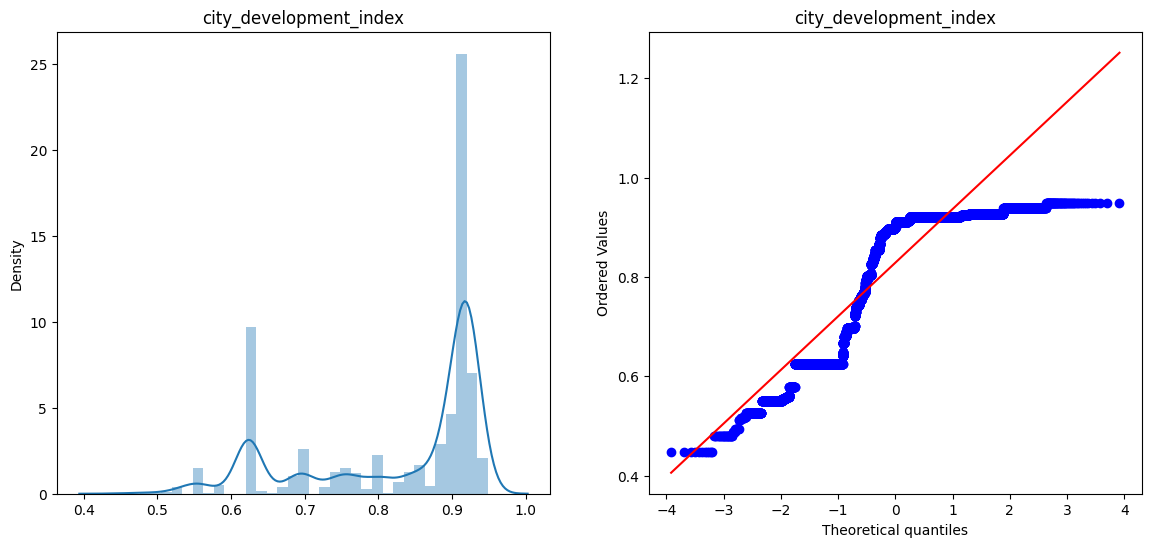

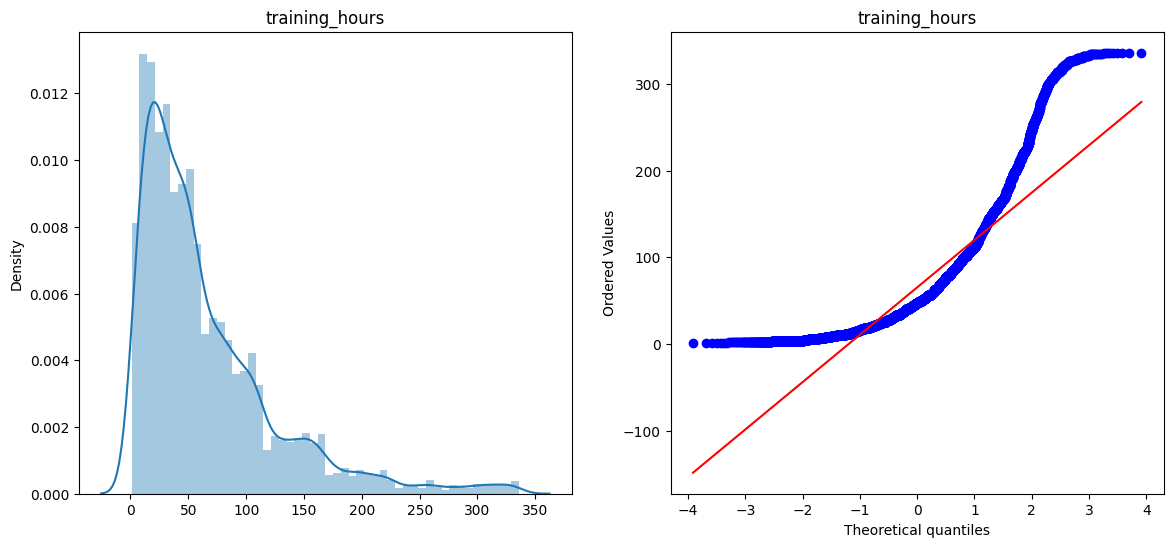

In [62]:
for cols in xx.columns:
  fig,(a1,a2)=plt.subplots(ncols=2,figsize=(14,6))
  sns.distplot(x=xx[cols],ax=a1)
  a1.set_title(f'{cols}')
  probplot(x=xx[cols],plot=a2)
  a2.set_title(f'{cols}')

In [117]:
trf3=ColumnTransformer([('transform1',PowerTransformer(),[-1])],remainder='passthrough')

In [118]:
pipe=Pipeline([('trf1',trf1),('trf2',trf2),('trf3',trf3)])

In [119]:
pipe.fit_transform(X_train)[0]

array([1.2119993629983614, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0,
       0.0, 2.0, 2.0, 1.0, 1.0, 0.624], dtype=object)

In [102]:
trf4_1=DecisionTreeClassifier()
trf4_2=LogisticRegression()
trf4_3=LinearRegression()

In [103]:
pipe1=Pipeline([('trf1',trf1),('trf2',trf2),('trf3',trf3),('trf4_1',trf4_1)])

In [104]:
pipe1.fit(X_train,Y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_data',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [3, 4, 5, 6, 7])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('transform',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [5, 2]),
                                                 ('encoded_Univesity_enrolled',
                                                  OrdinalEncode...
                                                  OrdinalEncoder(categories=[['never',
                                                                              '1',
                                                                              '2',
                                                                              '3',
                                                                              '4',
                                                                              '>4']]),
                                                  [4]),
                                                 ('encoded_relevent_experience',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'relevent '
                                                                              'experience',
                                                                              'Has '
                                                                              'relevent '
                                                                              'experience']]),
                                                  [7])])),
                ('trf3',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('transform2',
                                                  PowerTransformer(), [-2]),
                                                 ('transform1',
                                                  PowerTransformer(), [-1])])),
                ('trf4_1', DecisionTreeClassifier())])

In [120]:
pipe2=Pipeline([('trf1',trf1),('trf2',trf2),('trf3',trf3),('trf4_2',trf4_2)])

In [121]:
pipe2.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_data',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [3, 4, 5, 6, 7])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('transform',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [5, 2]),
                                                 ('encoded_Univesity_enrolled',
                                                  OrdinalEncode...
                                                 ('encoded_last_new_job',
                                                  OrdinalEncoder(categories=[['never',
                                                                              '1',
                                                                              '2',
                                                                              '3',
                                                                              '4',
                                                                              '>4']]),
                                                  [4]),
                                                 ('encoded_relevent_experience',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'relevent '
                                                                              'experience',
                                                                              'Has '
                                                                              'relevent '
                                                                              'experience']]),
                                                  [7])])),
                ('trf3',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('transform1',
                                                  PowerTransformer(), [-1])])),
                ('trf4_2', LogisticRegression())])

In [107]:
pipe3=Pipeline([('trf1',trf1),('trf2',trf2),('trf3',trf3),('trf4_3',trf4_3)])

In [108]:
pipe3.fit(X_train,Y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_data',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [3, 4, 5, 6, 7])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('transform',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [5, 2]),
                                                 ('encoded_Univesity_enrolled',
                                                  OrdinalEncode...
                                                  OrdinalEncoder(categories=[['never',
                                                                              '1',
                                                                              '2',
                                                                              '3',
                                                                              '4',
                                                                              '>4']]),
                                                  [4]),
                                                 ('encoded_relevent_experience',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'relevent '
                                                                              'experience',
                                                                              'Has '
                                                                              'relevent '
                                                                              'experience']]),
                                                  [7])])),
                ('trf3',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('transform2',
                                                  PowerTransformer(), [-2]),
                                                 ('transform1',
                                                  PowerTransformer(), [-1])])),
                ('trf4_3', LinearRegression())])

In [122]:
Y_pred1=pipe1.predict(X_test)
Y_pred2=pipe2.predict(X_test)
Y_pred3=pipe3.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [123]:
acc1=accuracy_score(Y_test,Y_pred1)
acc2=accuracy_score(Y_test,Y_pred2)
acc3=r2_score(Y_test,Y_pred3)

In [124]:
print(acc1,acc2,acc3)

0.6965031315240083 0.7828810020876826 0.17392872380841984


In [112]:
pipe_2=Pipeline([('trf1',trf1),('trf2',trf2),('trf4_2',trf4_2)])

In [113]:
pipe_2.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_data',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [3, 4, 5, 6, 7])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('transform',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [5, 2]),
                                                 ('encoded_Univesity_enrolled',
                                                  OrdinalEncode...
                                                                              '1',
                                                                              '2',
                                                                              '3',
                                                                              '4',
                                                                              '5',
                                                                              '6',
                                                                              '7',
                                                                              '8',
                                                                              '9',
                                                                              '10',
                                                                              '11',
                                                                              '12',
                                                                              '13',
                                                                              '14',
                                                                              '15',
                                                                              '16',
                                                                              '17',
                                                                              '18',
                                                                              '19',
                                                                              '20',
                                                                              '>20']]),
                                                  [3]),
                                                 ('encoded_last_new_job',
                                                  OrdinalEncoder(categories=[['never',
                                                                              '1',
                                                                              '2',
                                                                              '3',
                                                                              '4',
                                                                              '>4']]),
                                                  [4]),
                                                 ('encoded_relevent_experience',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'relevent '
                                                                              'experience',
                                                                              'Has '
                                                                              'relevent '
                                                                              'experience']]),
             

In [115]:
Y_pred_2=pipe_2.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [116]:
accuracy_score(Y_test,Y_pred_2)

0.7794885177453027

In [127]:
np.mean(cross_val_score(pipe2,X_train,Y_train,cv=5))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

np.float64(0.7773064574999814)

In [128]:
np.mean(cross_val_score(pipe_2,X_train,Y_train,cv=5))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

np.float64(0.7744358426737922)

In [129]:
import pickle
pickle.dump(pipe2,open('model.pkl','wb'))